# Overview

This notebook builds on the EDA findings to train and evaluate models predicting `Will_Buy_EV`.

**Task**: binary classification, imbalanced target (82.5% No / 17.5% Yes).

**Metric**: AUC-ROC, matching the competition's evaluation criteria and robust to the imbalance.

**Key predictors identified during EDA**: `Subsidy_Available` and `Range_Anxiety_Level` (near-deterministic), `Home_Charging_Possible` (moderate signal). Other numeric features (income, commute, charging station counts) showed weak individual correlation with the target but may contribute through interactions.

**Approach**: stratified train/validation split (and stratified k-fold CV), ordinal/one-hot encoding for categoricals per EDA recommendations, baseline model first, then tree-based models (LightGBM/XGBoost) expected to perform well given the mostly categorical, synthetic nature of the data.

In [28]:
from IPython.display import Image

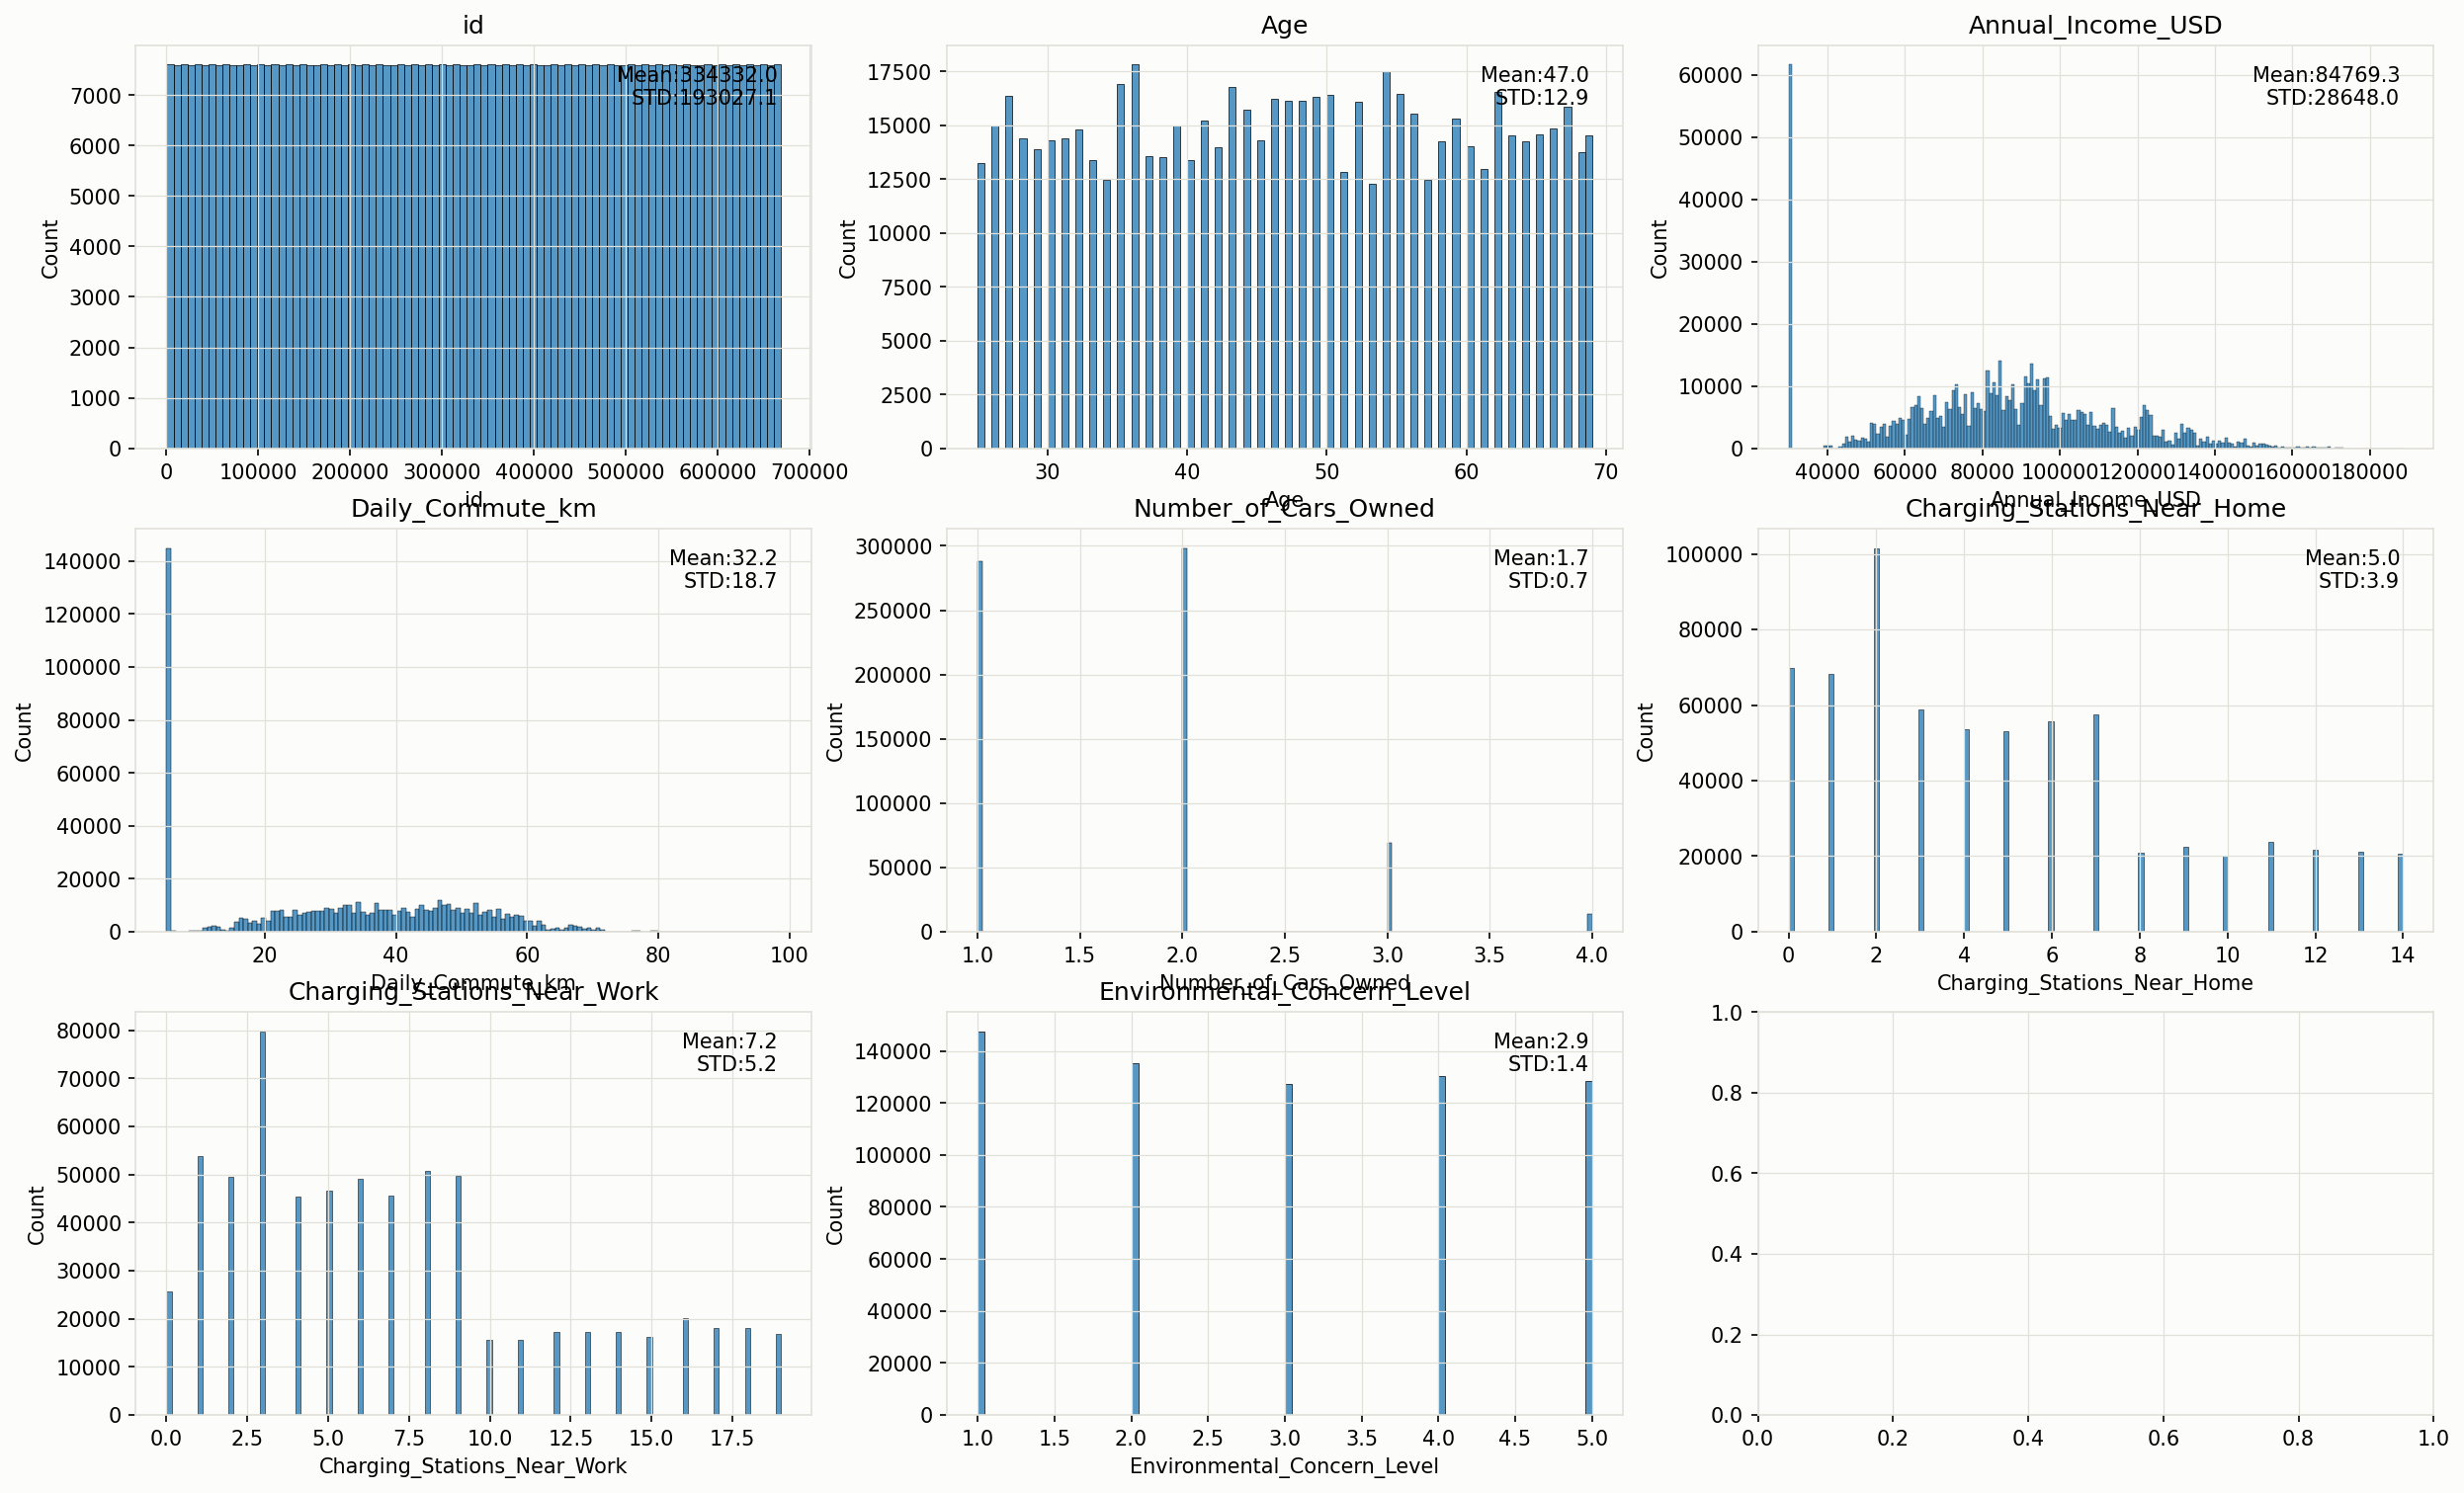

In [29]:
Image("../charts/numeric_distributions.png")

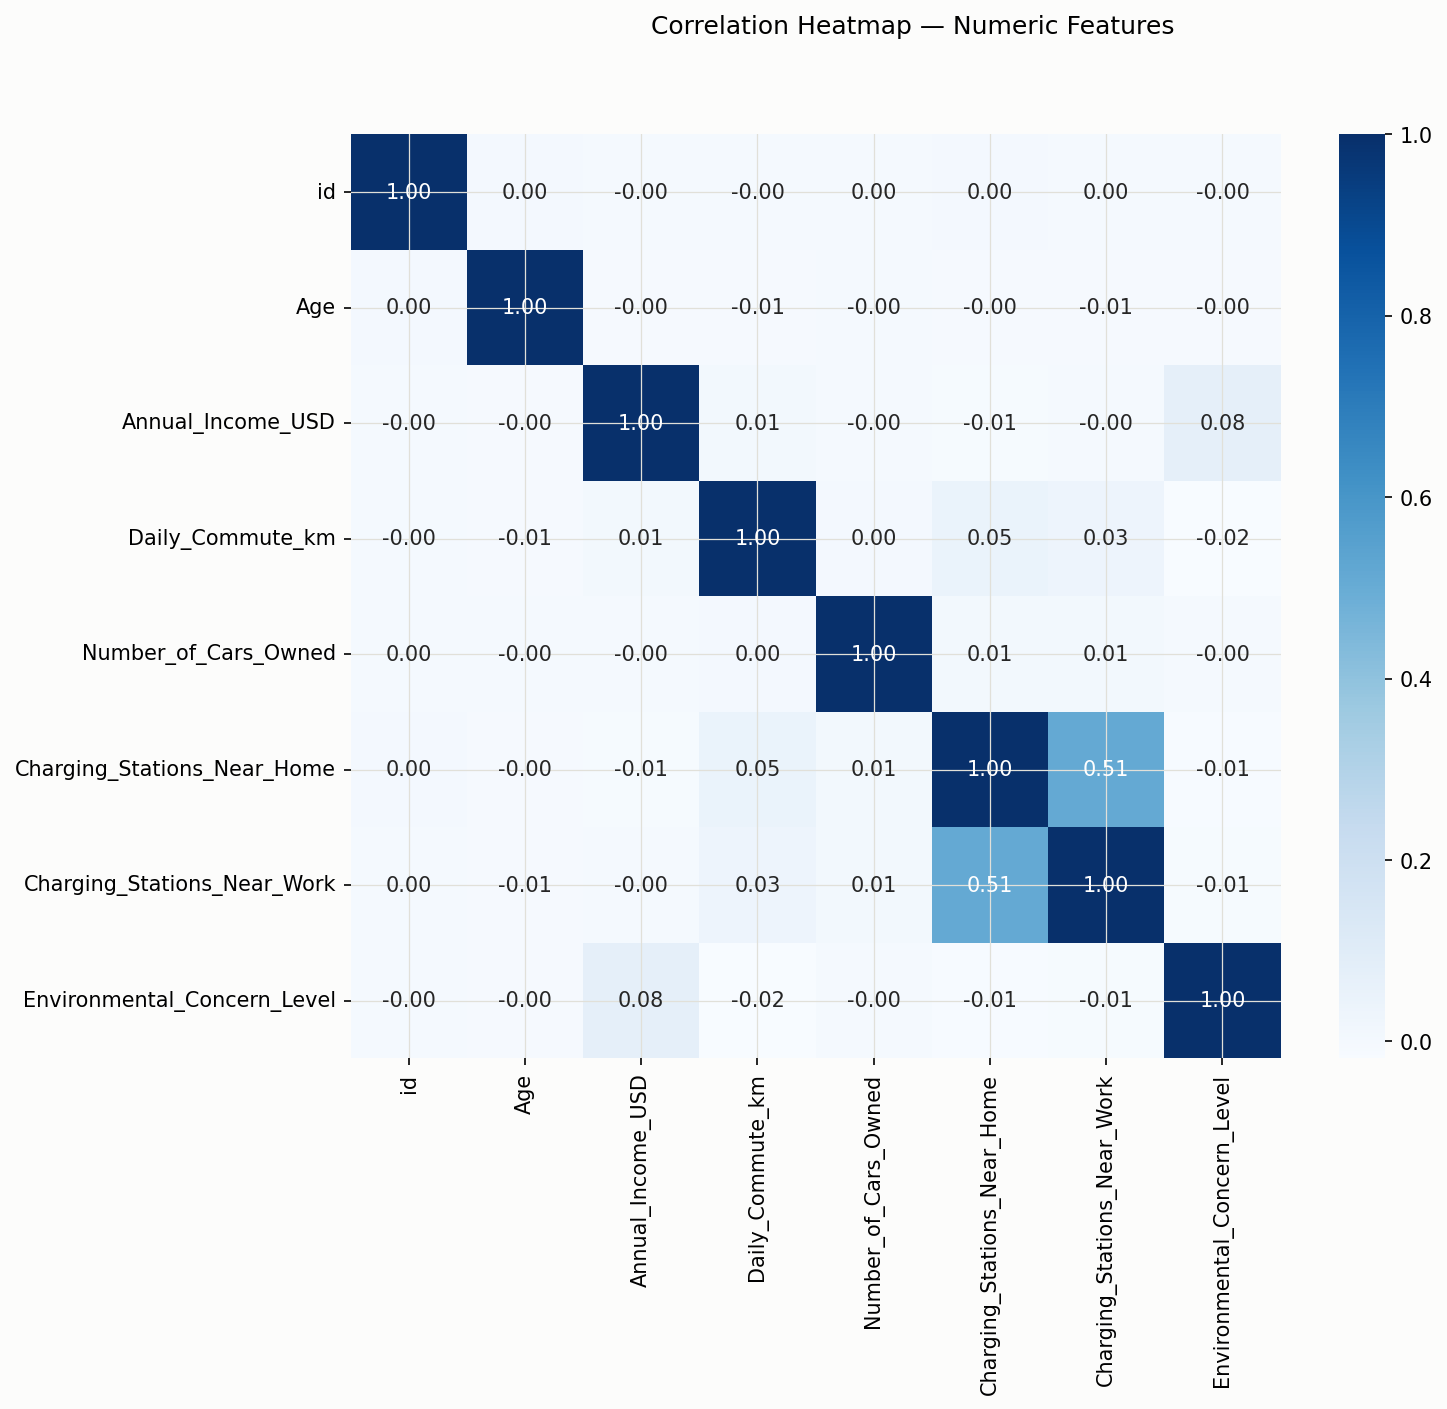

In [30]:
Image("../charts/correlation_heatmap.png")

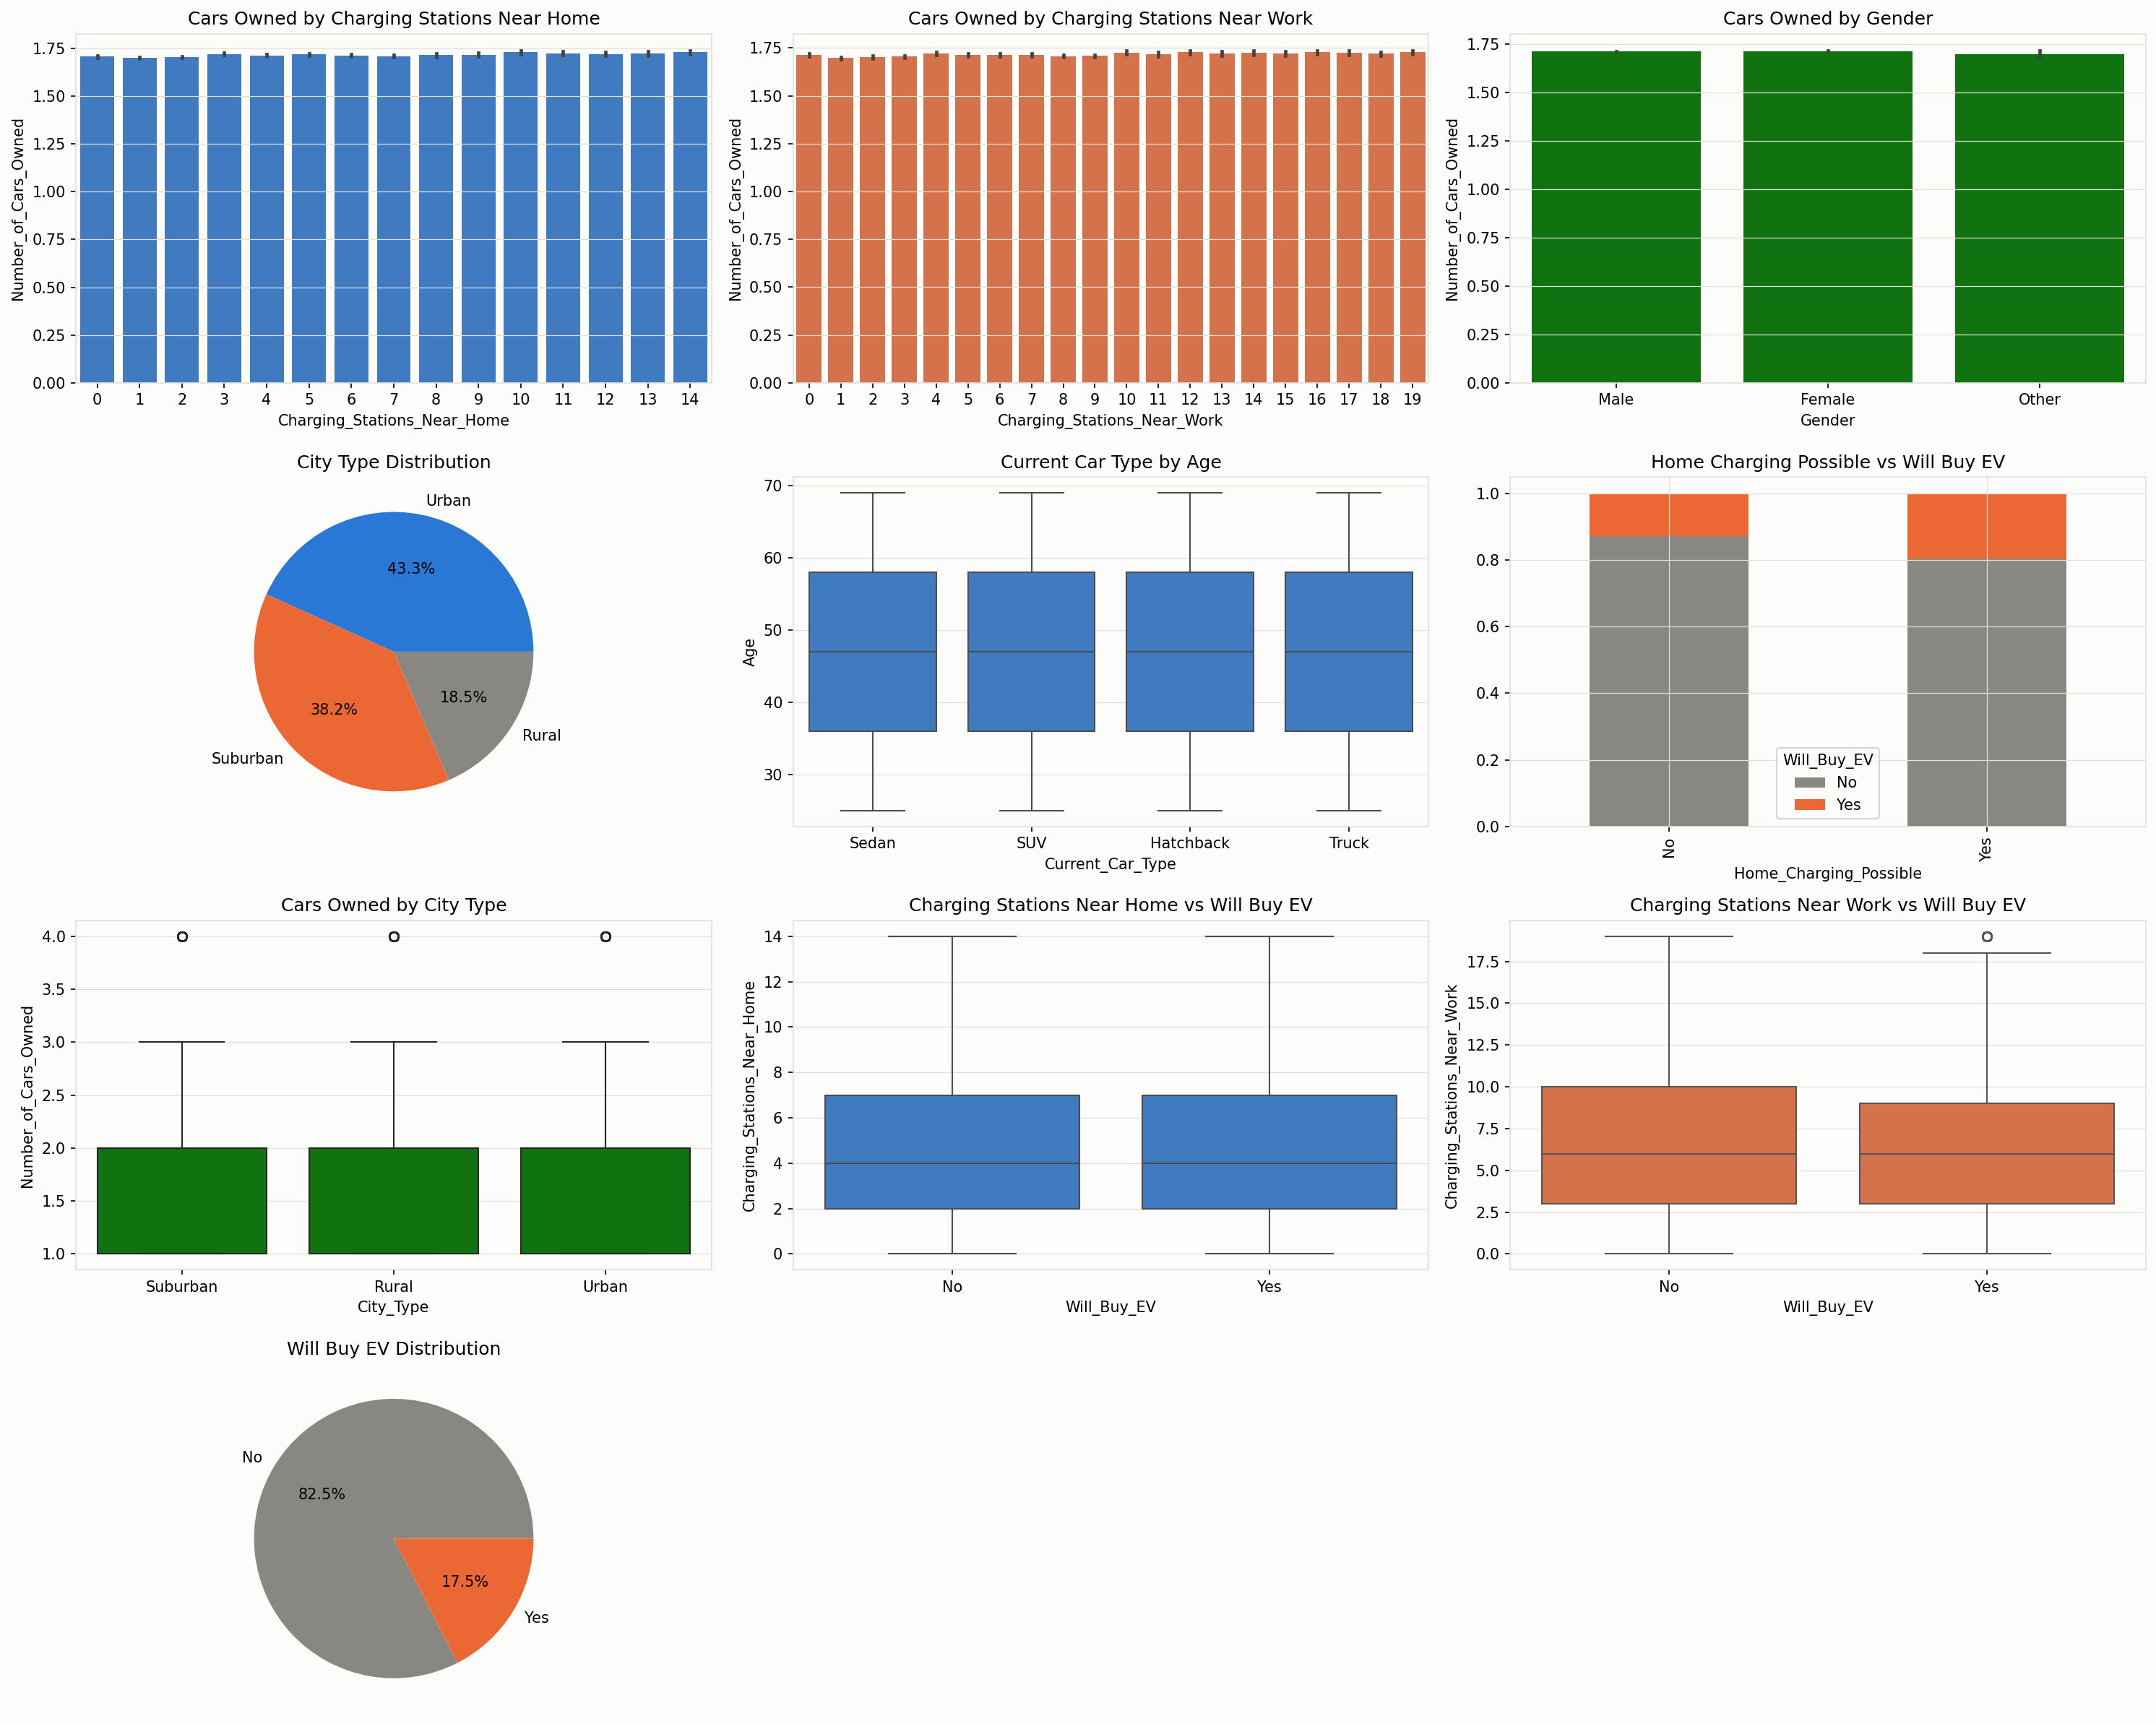

In [31]:
Image("../charts/relationship_analysis.png")

# EDA Summary

**Distributions**: Age and Environmental_Concern_Level are roughly uniform. Annual_Income_USD and Daily_Commute_km show floor artifacts (30,000 and 5.0) followed by right-skewed tails — synthetic generator behavior, not real outliers. Number_of_Cars_Owned and Charging_Stations counts are discrete/multimodal.

**Correlations**: numeric features are essentially independent of each other, except Charging_Stations_Near_Home ↔ Near_Work (0.51). No multicollinearity concerns.

**Relationships with target**: `Subsidy_Available` and `Range_Anxiety_Level` are near-deterministic predictors (established earlier via groupby). `Home_Charging_Possible` shows a clear, moderate effect. Charging station counts, cars owned, and demographic features show little to no relationship with `Will_Buy_EV`.

**Conclusion**: this is a synthetic Playground Series dataset with a small set of dominant categorical predictors driving the target, and mostly noise elsewhere. Feature engineering should focus on encoding and combining the strong predictors (Subsidy_Available, Range_Anxiety_Level, Home_Charging_Possible) rather than deep engineering on the weak numeric features. Target imbalance (82.5/17.5) requires stratified splitting and AUC-ROC as the evaluation metric.

# Preprocessing

## Review the data 

In [32]:
import pandas as pd
import numpy as np

In [33]:
train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")
sample_submission = pd.read_csv("../data/raw/sample_submission.csv")

In [34]:
for i , name in [("train",train),("test",test)]:
    missing = name.isna().sum().sum()
    print(missing)

0
0


In [35]:
for i , name in [("train",train),("test",test)]:
    print(f"{i} :\n {name.dtypes}")

train :
 id                               int64
Age                              int64
Annual_Income_USD              float64
Daily_Commute_km               float64
Number_of_Cars_Owned             int64
Charging_Stations_Near_Home      int64
Charging_Stations_Near_Work      int64
Environmental_Concern_Level    float64
Gender                          object
City_Type                       object
Current_Car_Type                object
Home_Charging_Possible          object
Subsidy_Available               object
Range_Anxiety_Level             object
Will_Buy_EV                     object
dtype: object
test :
 id                               int64
Age                              int64
Annual_Income_USD              float64
Daily_Commute_km               float64
Number_of_Cars_Owned             int64
Charging_Stations_Near_Home      int64
Charging_Stations_Near_Work      int64
Environmental_Concern_Level    float64
Gender                          object
City_Type                       o

# Overview Preprocessing

Loaded `train.csv`, `test.csv`, and `sample_submission.csv`.

No missing values in either train or test.

Confirmed dtypes: numeric features (`Age`, `Annual_Income_USD`, `Daily_Commute_km`, `Number_of_Cars_Owned`, `Charging_Stations_Near_Home`, `Charging_Stations_Near_Work`, `Environmental_Concern_Level`) are already int64/float64. Categorical features (`Gender`, `City_Type`, `Current_Car_Type`, `Home_Charging_Possible`, `Subsidy_Available`, `Range_Anxiety_Level`) plus the target `Will_Buy_EV` are objects — will need encoding before modeling.

# Feature Engineering


In [36]:
# 1. Binary Yes/No categoricals -> 0/1
binary_map = {"Yes": 1, "No": 0}
for col in ["Home_Charging_Possible", "Subsidy_Available"]:
    train[col] = train[col].map(binary_map)
    test[col] = test[col].map(binary_map)

# 2. Range_Anxiety_Level -> ordinal (Low < Medium < High)
anxiety_map = {"Low": 0, "Medium": 1, "High": 2}
train["Range_Anxiety_Level"] = train["Range_Anxiety_Level"].map(anxiety_map)
test["Range_Anxiety_Level"] = test["Range_Anxiety_Level"].map(anxiety_map)

# 3. One-hot encode remaining nominal categoricals (no natural order)
nominal_cols = ["Gender", "City_Type", "Current_Car_Type"]
train = pd.get_dummies(train, columns=nominal_cols, drop_first=True)
test = pd.get_dummies(test, columns=nominal_cols, drop_first=True)

# 4. Target -> binary
train["Will_Buy_EV"] = train["Will_Buy_EV"].map({"Yes": 1, "No": 0})

# 5. Interaction feature: subsidy x low range anxiety (both strong individual signals)
train["Subsidy_LowAnxiety"] = train["Subsidy_Available"] * (train["Range_Anxiety_Level"] == 0).astype(int)
test["Subsidy_LowAnxiety"] = test["Subsidy_Available"] * (test["Range_Anxiety_Level"] == 0).astype(int)

# 6. Combined charging access
train["Total_Charging_Access"] = train["Charging_Stations_Near_Home"] + train["Charging_Stations_Near_Work"]
test["Total_Charging_Access"] = test["Charging_Stations_Near_Home"] + test["Charging_Stations_Near_Work"]

# 7. Drop id (not a feature)
train = train.drop(columns=["id"])
X_test_ids = test["id"]
test = test.drop(columns=["id"])

train.head()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV,Gender_Male,Gender_Other,City_Type_Suburban,City_Type_Urban,Current_Car_Type_SUV,Current_Car_Type_Sedan,Current_Car_Type_Truck,Subsidy_LowAnxiety,Total_Charging_Access
0,66,92887.0,23.4,2,3,7,1.0,1,0,0,0,True,False,True,False,False,True,False,0,10
1,38,30000.0,5.0,1,2,2,4.0,1,0,0,0,True,False,False,False,True,False,False,0,4
2,26,94389.0,36.8,1,8,15,5.0,0,1,0,1,False,False,False,True,False,True,False,1,23
3,66,73580.0,23.7,2,6,9,3.0,1,0,0,0,True,False,True,False,False,False,False,0,15
4,54,57898.0,50.8,1,2,3,3.0,1,0,0,0,True,False,True,False,False,False,False,0,5


In [37]:
def add_features(train, test):
    for df in [train, test]:
        # Ratio / composite charging features
        df["Charging_Station_Diff"] = df["Charging_Stations_Near_Home"] - df["Charging_Stations_Near_Work"]
        df["Charging_Station_Ratio"] = df["Charging_Stations_Near_Home"] / (df["Charging_Stations_Near_Work"] + 1)
        df["Cars_Per_ChargingHome"] = df["Number_of_Cars_Owned"] / (df["Charging_Stations_Near_Home"] + 1)
        df["Commute_Per_ChargingWork"] = df["Daily_Commute_km"] / (df["Charging_Stations_Near_Work"] + 1)

        # Interactions with the strong predictors
        df["Subsidy_HomeCharging"] = df["Subsidy_Available"] * df["Home_Charging_Possible"]
        df["Subsidy_EnvConcern"] = df["Subsidy_Available"] * df["Environmental_Concern_Level"]
        df["Anxiety_EnvConcern"] = df["Range_Anxiety_Level"] * df["Environmental_Concern_Level"]
        df["Anxiety_HomeCharging"] = df["Range_Anxiety_Level"] * df["Home_Charging_Possible"]
        df["Subsidy_Anxiety_Home"] = df["Subsidy_Available"] * df["Home_Charging_Possible"] * (df["Range_Anxiety_Level"] == 0).astype(int)

        # Income / commute ratios
        df["Income_Per_Car"] = df["Annual_Income_USD"] / df["Number_of_Cars_Owned"].replace(0, 1)
        df["Commute_Per_Car"] = df["Daily_Commute_km"] / df["Number_of_Cars_Owned"].replace(0, 1)
        df["Income_Per_Commute"] = df["Annual_Income_USD"] / (df["Daily_Commute_km"] + 1)

        # Binned/flag features
        df["High_EnvConcern"] = (df["Environmental_Concern_Level"] >= 4).astype(int)
        df["High_Income"] = (df["Annual_Income_USD"] > df["Annual_Income_USD"].median()).astype(int)
        df["Long_Commute"] = (df["Daily_Commute_km"] > df["Daily_Commute_km"].median()).astype(int)
        df["Age_Group"] = pd.cut(df["Age"], bins=[0, 35, 50, 100], labels=["Young", "Mid", "Senior"]).astype(str)
        df["Multi_Car"] = (df["Number_of_Cars_Owned"] > 1).astype(int)

        # City / vehicle type flags
        df["Is_Urban"] = (df["City_Type_Urban"] == 1).astype(int) if "City_Type_Urban" in df.columns else 0
        df["Total_Charging_Access"] = df["Charging_Stations_Near_Home"] + df["Charging_Stations_Near_Work"]
        df["ChargingHome_x_Subsidy"] = df["Charging_Stations_Near_Home"] * df["Subsidy_Available"]
        df["ChargingWork_x_Subsidy"] = df["Charging_Stations_Near_Work"] * df["Subsidy_Available"]

    return train, test

train, test = add_features(train, test)

# Define X & Y 

In [38]:
x = train.drop(columns = "Will_Buy_EV") 
y = train["Will_Buy_EV"]
obj = train.select_dtypes(include = "object").columns.tolist()

# Train_test_split

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
x_train, x_val, y_train, y_val = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42)

# Model 

In [41]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [42]:
models = {
    "LightGBM": lgb.LGBMClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric="logloss")}

# Evaluation

In [43]:
for name , model in models.items():
    pipe = Pipeline([
        ("transformer",ColumnTransformer([("one_hot",OneHotEncoder(drop="first", handle_unknown="ignore"),obj)]
                                         ,remainder= "passthrough")),
        ("scaler",StandardScaler()),
        ("model",model)])
    pipe.fit(x_train,y_train)
    y_pred = pipe.predict_proba(x_val)[:, 1]
    auc = roc_auc_score(y_val,y_pred)
    print(f"{name}: AUC = {auc:.4f}")
    

[LightGBM] [Info] Number of positive: 93423, number of negative: 441509
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017173 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2007
[LightGBM] [Info] Number of data points in the train set: 534932, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.174645 -> initscore=-1.553061
[LightGBM] [Info] Start training from score -1.553061


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM: AUC = 0.9410
XGBoost: AUC = 0.9409


# adding some features

In [44]:
lgb_pipe = Pipeline([
        ("transformer",ColumnTransformer([("one_hot",OneHotEncoder(drop="first", handle_unknown="ignore"),obj)]
                                         ,remainder= "passthrough")),
        ("scaler",StandardScaler()),
        ("model",lgb.LGBMClassifier(random_state=42))])

In [45]:
def add_feature(train, test):
    income_mean = train["Annual_Income_USD"].mean()
    commute_mean = train["Daily_Commute_km"].mean()

    for df in [train, test]:
        df["Has_Work_Charging"] = (df["Charging_Stations_Near_Work"] > 0).astype(int)
        df["High_Income"] = (df["Annual_Income_USD"] > income_mean).astype(int)
        df["Low_Commute"] = (df["Daily_Commute_km"] < commute_mean).astype(int)
        df["High_EnvConcern"] = (df["Environmental_Concern_Level"] >= 4).astype(int)
        df["Young_Age"] = (df["Age"] < train["Age"].median()).astype(int)
        df["Multi_Car_Owner"] = (df["Number_of_Cars_Owned"] > 1).astype(int)
        df["Urban_Resident"] = df["City_Type_Urban"] if "City_Type_Urban" in df.columns else 0
        df["Subsidy_And_LowAnxiety"] = ((df["Subsidy_Available"] == 1) & (df["Range_Anxiety_Level"] == 0)).astype(int)
        df["HomeAndWork_Charging"] = ((df["Home_Charging_Possible"] == 1) & (df["Has_Work_Charging"] == 1)).astype(int)
        df["EV_Readiness_Score"] = (
            df["Home_Charging_Possible"] + df["Has_Work_Charging"] + df["High_Income"]
            + df["Subsidy_Available"] + (2 - df["Range_Anxiety_Level"])
        )

    return train, test

train, test = add_feature(train, test)

In [46]:
test.head()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,...,ChargingHome_x_Subsidy,ChargingWork_x_Subsidy,Has_Work_Charging,Low_Commute,Young_Age,Multi_Car_Owner,Urban_Resident,Subsidy_And_LowAnxiety,HomeAndWork_Charging,EV_Readiness_Score
0,61,67725.0,16.9,2,7,4,4.0,1,0,0,...,0,0,1,1,0,1,False,0,1,4
1,42,152835.0,41.9,2,9,9,4.0,0,0,0,...,0,0,1,0,1,1,True,0,0,4
2,68,86877.0,53.3,1,10,11,4.0,0,0,0,...,0,0,1,0,0,0,True,0,0,4
3,39,46794.0,34.1,2,4,8,4.0,1,0,0,...,0,0,1,0,1,1,False,0,1,4
4,55,112172.0,57.2,1,6,4,1.0,1,1,0,...,6,4,1,0,0,0,False,1,1,6


# Model II

In [47]:
obj = train.select_dtypes(include="object").columns.tolist()

model_2_pipe = Pipeline([
    ("transformer", ColumnTransformer([("one_hot", OneHotEncoder(drop="first", handle_unknown="ignore"), obj)],
                                       remainder="passthrough")),
    ("model", lgb.LGBMClassifier(
        n_estimators=1000,
        max_depth=3,
        learning_rate=0.1,
        num_leaves=31,
        subsample=0.6,
        colsample_bytree=0.8,
        random_state=42
    ))
])

model_2_pipe.fit(x_train, y_train)
y_pred_2 = model_2_pipe.predict_proba(x_val)[:, 1]
auc_2 = roc_auc_score(y_val, y_pred_2)
print("Model 2 AUC:", auc_2)

[LightGBM] [Info] Number of positive: 93423, number of negative: 441509
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035504 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1977
[LightGBM] [Info] Number of data points in the train set: 534932, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.174645 -> initscore=-1.553061
[LightGBM] [Info] Start training from score -1.553061
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Model 2 AUC: 0.9416748923530471


# save

In [48]:
import joblib

joblib.dump(model_2_pipe, "../trained_model/model.pkl")

['../trained_model/model.pkl']